### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Yunnqi Liu
*   Your **student number**: 1005760598



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [1]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [4]:
### YOUR CODE HERE ###
countries_text = requests.get(countries_list_url, headers=headers).text

countries = [
    country.strip()
    for country in countries_text.splitlines()
    if country.strip()
]

population_df = raw_data[
    raw_data["entity"].isin(countries)
    & raw_data["year"].between(1901, 2023)
].copy()

population_df["population_historical"] = pd.to_numeric(
    population_df["population_historical"],
    errors="coerce"
)

population_df = population_df.pivot(
    index="entity",
    columns="year",
    values="population_historical"
)

population_df = population_df.reindex(columns=range(1901, 2024))

population_df = population_df.where(population_df > 0)

population_df = population_df.dropna(axis=0)

population_df.index.name = None
population_df.columns.name = None

print(population_df.shape)
population_df.head()

(196, 123)


,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

Tunisia fluctuates but declines overall, Australia rises early then slightly falls, and Japan rises until around 1950 and then steadily declines. An upward curve means the country’s population is increasing relative to other countries in that year; a downward curve means it is decreasing relatively. Positive values mean above the yearly average population, while negative values mean below the yearly average.

In [14]:
### YOUR CODE HERE ###
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
def plot_countries(df, countries, title):
    valid_countries = [country for country in countries if country in df.index]

    if not valid_countries:
        print("No valid countries found.")
        return

    fig, axes = plt.subplots(
        len(valid_countries),
        1,
        figsize=(12, 3 * len(valid_countries)),
        sharex=True
    )
    if len(valid_countries) == 1:
        axes = [axes]

    for ax, country in zip(axes, valid_countries):
        ax.plot(df.columns, df.loc[country])
        ax.set_title(country)
        ax.set_ylabel("Population")
        ax.grid(True)

    axes[-1].set_xlabel("Year")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [15]:
scaler = StandardScaler()

standardized_values = scaler.fit_transform(population_df)

standardized_df = pd.DataFrame(
    standardized_values,
    index=population_df.index,
    columns=population_df.columns
)

# Check that each year has approximately mean 0 and standard deviation 1
print("Largest absolute yearly mean:",
      np.abs(standardized_df.mean(axis=0)).max())

print("Yearly standard deviations:")
print(standardized_df.std(axis=0, ddof=0).describe())

Largest absolute yearly mean: 4.531522549490435e-17
Yearly standard deviations:
count    1.230000e+02
mean     1.000000e+00
std      2.568543e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


In [17]:
!pip install python-Levenshtein -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.0 MB/s eta 0:00:00


In [22]:
import Levenshtein

name = "Yunqi Liu"

country_distances = sorted(
    [
        (country, Levenshtein.distance(
            name.lower(),
            country.lower()
        ))
        for country in population_df.index
    ],
    key=lambda x: (x[1], x[0])
)

closest_two = [country for country, distance in country_distances[:2]]

print("Closest countries:", closest_two)
print("Distances:", country_distances[:2])

Closest countries: ['Tunisia', 'Australia']
Distances: [('Tunisia', 5), ('Australia', 6)]


Selected countries: ['Tunisia', 'Australia', 'Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']


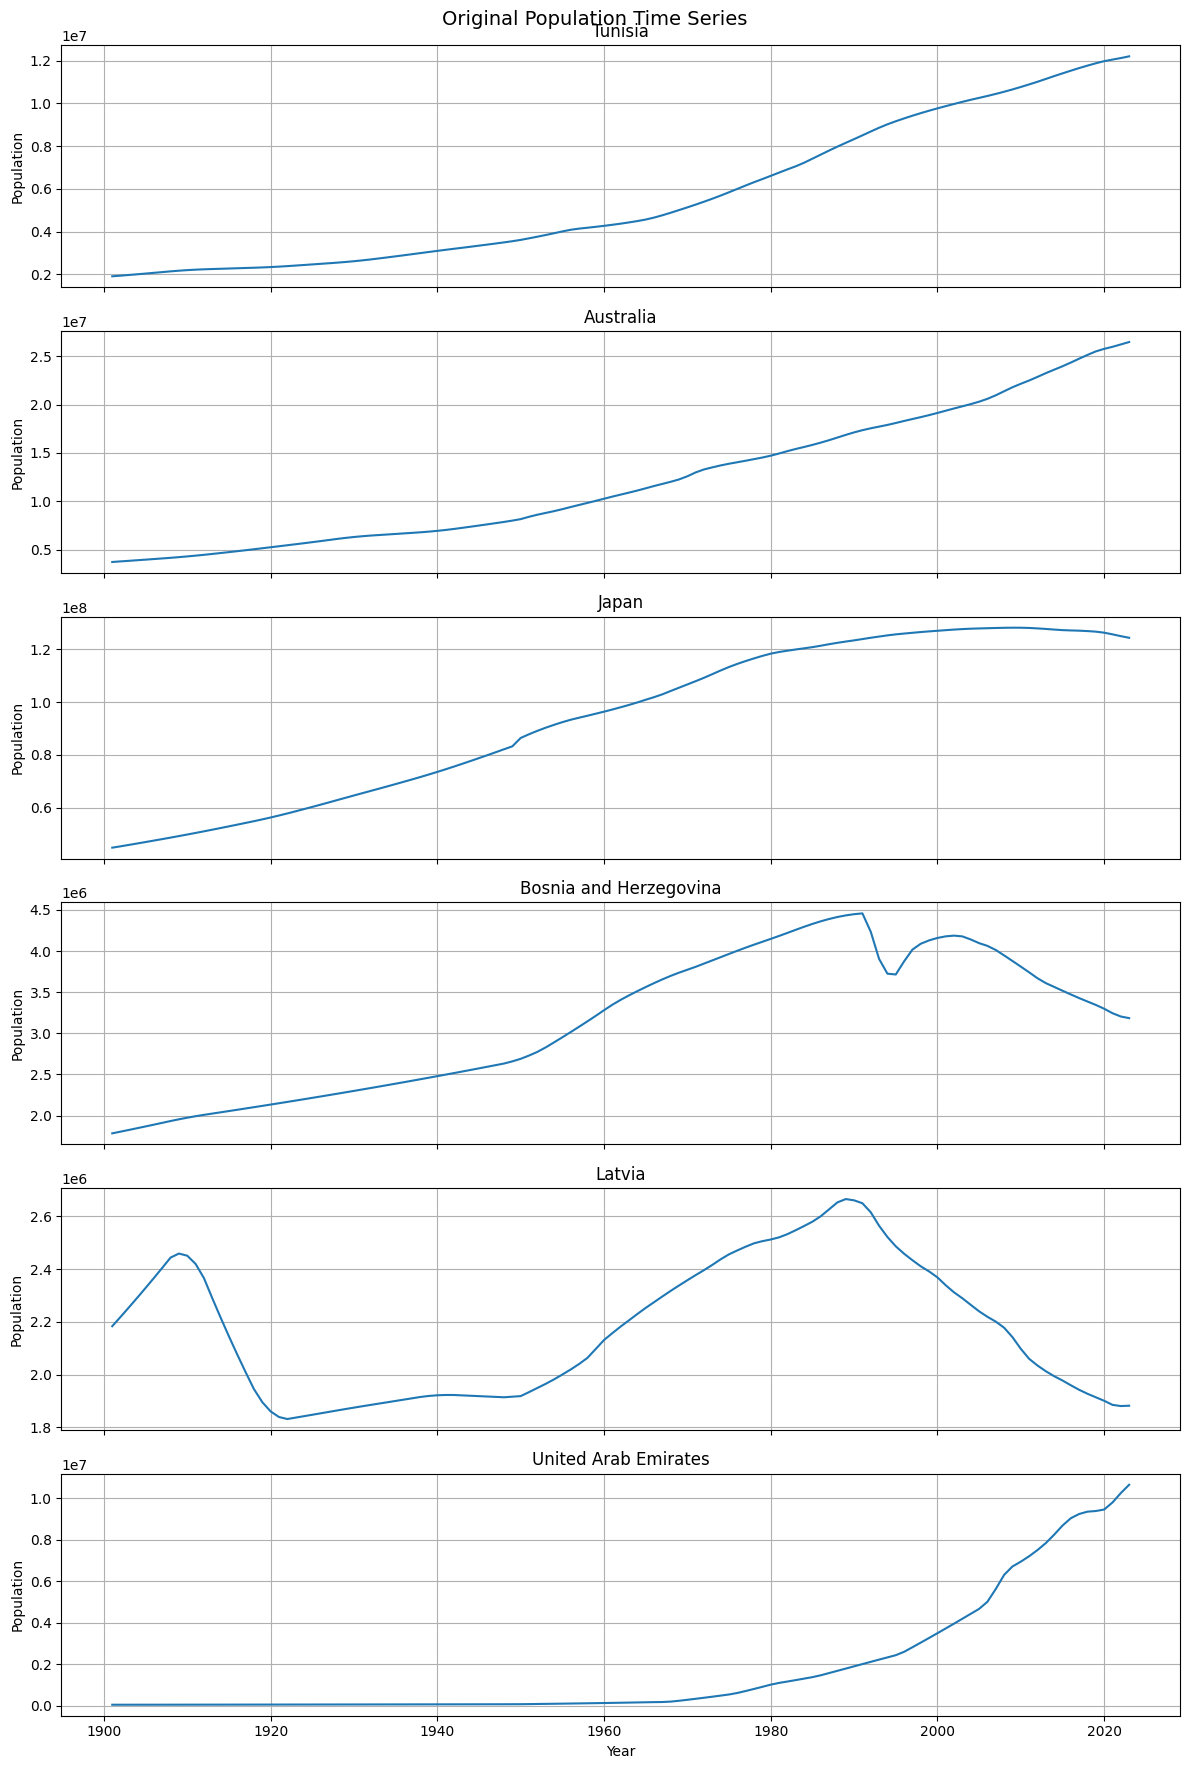

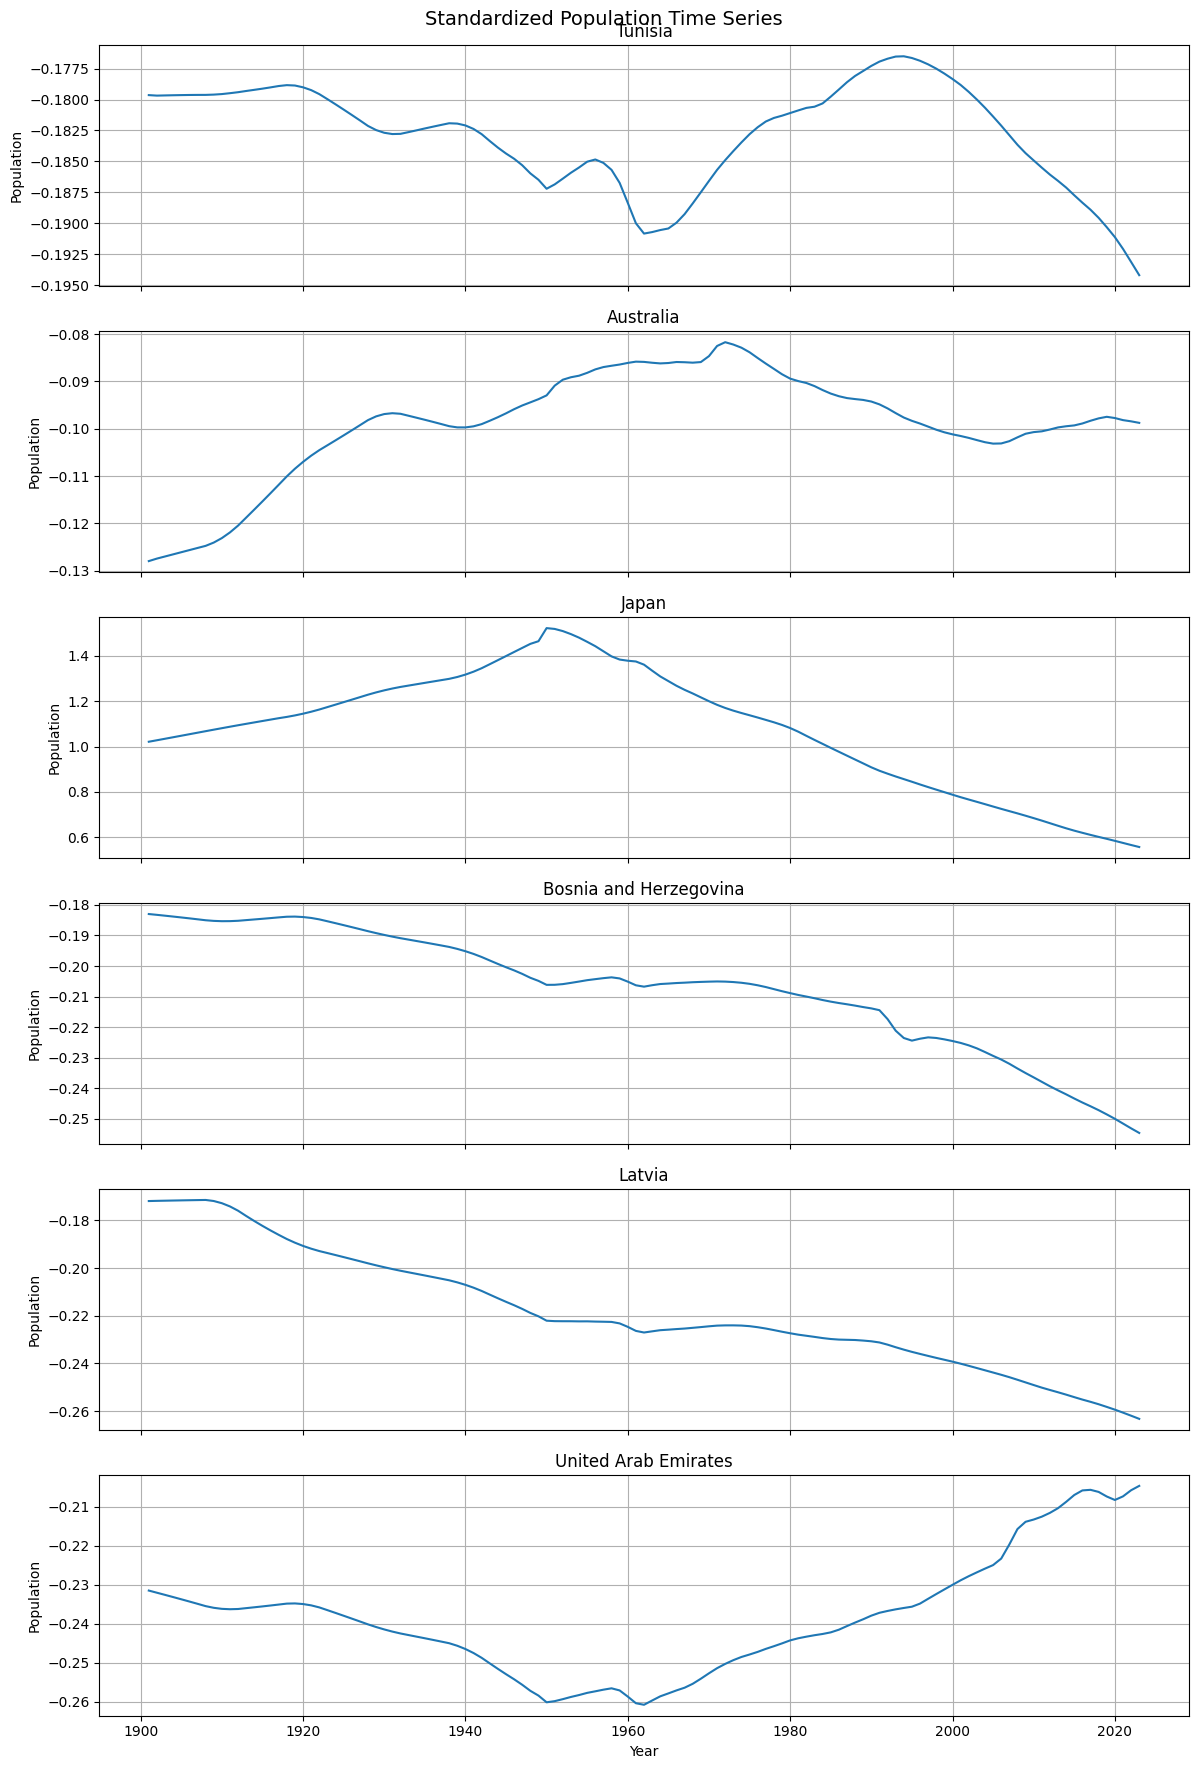

In [25]:

required_countries = [
    "Japan",
    "Bosnia and Herzegovina",
    "Latvia",
    "United Arab Emirates"
]
selected_countries = closest_two + required_countries

print("Selected countries:", selected_countries)

plot_countries(
    population_df,
    selected_countries,
    "Original Population Time Series"
)

plot_countries(
    standardized_df,
    selected_countries,
    "Standardized Population Time Series"
)